In [1]:
import pandas as pd
import matplotlib.pyplot as plt

companies = pd.read_excel("../data/clean/companies_clean.xlsx")
balancesheet = pd.read_excel("../data/clean/balancesheet_clean.xlsx")
profit = pd.read_excel("../data/clean/profitandloss_clean.xlsx")
cashflow = pd.read_excel("../data/clean/cashflow_clean.xlsx")

In [2]:
profit_cols = [
    "sales",
    "expenses",
    "operating_profit",
    "net_profit",
    "eps"
]

for col in profit_cols:
    profit[col] = pd.to_numeric(
        profit[col],
        errors="coerce"
    )

balance_cols = [
    "borrowings",
    "reserves",
    "total_assets"
]

for col in balance_cols:
    balancesheet[col] = pd.to_numeric(
        balancesheet[col],
        errors="coerce"
    )

cash_cols = [
    "operating_activity",
    "investing_activity",
    "financing_activity",
    "net_cash_flow"
]

for col in cash_cols:
    cashflow[col] = pd.to_numeric(
        cashflow[col],
        errors="coerce"
    )

In [3]:
top_sales = (
    profit.groupby("company_id")["sales"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(top_sales)

company_id
RELIANCE      939838
LICI          896106
IOC           841756
ONGC          658694
BPCL          473187
SBIN          469625
TATAMOTORS    440061
HDFCBANK      329022
TCS           252082
TATASTEEL     243959
Name: sales, dtype: int64


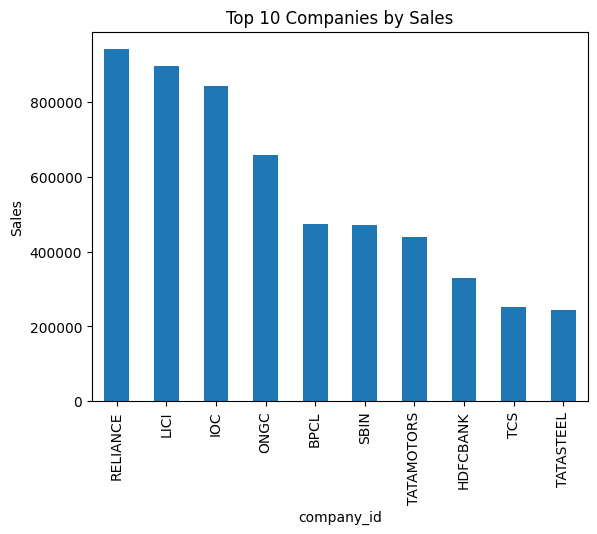

In [4]:
top_sales.plot(kind="bar")

plt.title("Top 10 Companies by Sales")
plt.ylabel("Sales")
plt.show()

In [5]:
top_profit = (
    profit.groupby("company_id")["net_profit"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(top_profit)

company_id
RELIANCE     79941
SBIN         74461
HDFCBANK     72168
ONGC         57101
ICICIBANK    52416
TCS          49006
IOC          43161
TATASTEEL    41749
LICI         41468
COALINDIA    37369
Name: net_profit, dtype: int64


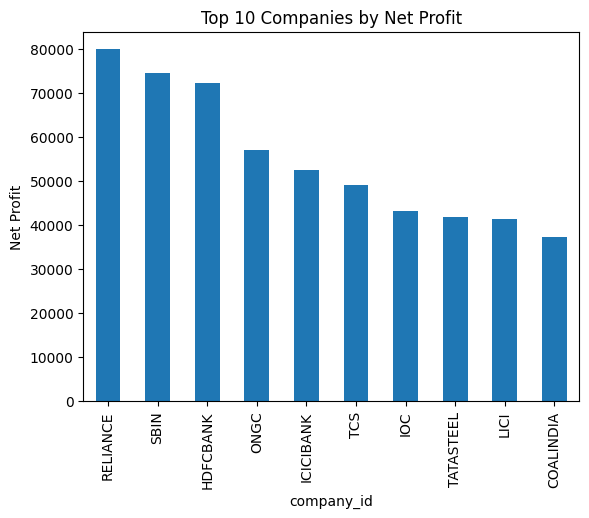

In [6]:
top_profit.plot(kind="bar")

plt.title("Top 10 Companies by Net Profit")
plt.ylabel("Net Profit")
plt.show()

In [7]:
top_debt = (
    balancesheet.groupby("company_id")["borrowings"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(top_debt)

company_id
HDFCBANK      3107503
ICICIBANK     1651008
BANKBARODA    1453761
CANBK         1369780
AXISBANK      1295302
UNIONBANK     1251568
PFC            910447
KOTAKBANK      520374
RECLTD         483617
RELIANCE       458991
Name: borrowings, dtype: int64


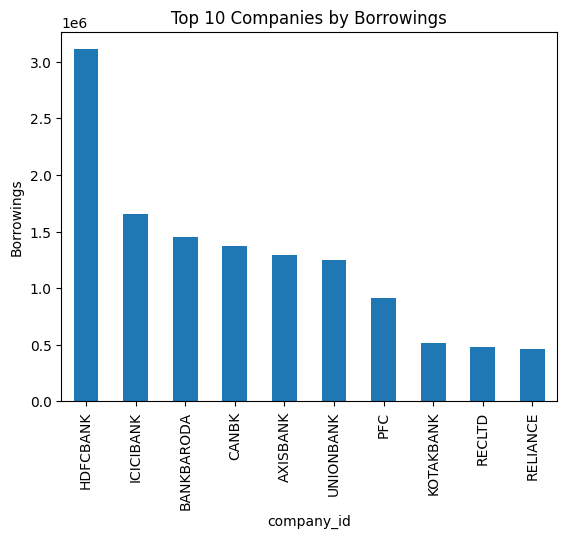

In [8]:
top_debt.plot(kind="bar")

plt.title("Top 10 Companies by Borrowings")
plt.ylabel("Borrowings")
plt.show()

In [9]:
top_cash = (
    cashflow.groupby("company_id")["operating_activity"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(top_cash)

company_id
RELIANCE      158788.0
ICICIBANK     157284.0
ONGC           99263.0
SBIN           89919.0
LICI           80602.0
BHARTIARTL     78898.0
IOC            71099.0
TATAMOTORS     67915.0
CANBK          59118.0
NTPC           47152.0
Name: operating_activity, dtype: float64


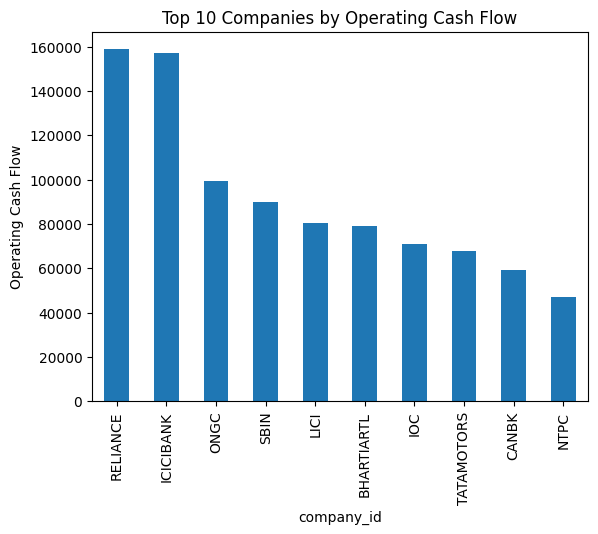

In [10]:
top_cash.plot(kind="bar")

plt.title("Top 10 Companies by Operating Cash Flow")
plt.ylabel("Operating Cash Flow")
plt.show()

In [11]:
master = profit.merge(
    balancesheet,
    on=["company_id","year"],
    how="left"
)

master = master.merge(
    cashflow,
    on=["company_id","year"],
    how="left"
)

master.head()

,id_x,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,...,fixed_assets,cwip,investments,other_asset,total_assets,id,operating_activity,investing_activity,financing_activity,net_cash_flow
0,61,ABB,Dec 2012,1653,1451,202.0,12.0,33,0,19,...,109.0,1.0,0.0,798.0,907.0,61.0,101.0,-59.0,-42.0,1.0
1,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,...,98.0,1.0,0.0,1040.0,1139.0,62.0,155.0,-144.0,-42.0,-31.0
2,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,...,98.0,1.0,0.0,1040.0,1139.0,73.0,0.0,0.0,0.0,0.0
3,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,...,96.0,4.0,0.0,1274.0,1374.0,63.0,215.0,-187.0,-58.0,-30.0
4,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,...,96.0,4.0,0.0,1274.0,1374.0,74.0,-35.0,-1864.0,1902.0,3.0


In [12]:
master["net_profit_margin"] = (
    master["net_profit"] /
    master["sales"]
) * 100

master["debt_equity"] = (
    master["borrowings"] /
    (
        master["equity_capital"] +
        master["reserves"]
    )
)

master.head()

,id_x,company_id,year,sales,expenses,operating_profit,opm_percentage,other_income,interest,depreciation,...,investments,other_asset,total_assets,id,operating_activity,investing_activity,financing_activity,net_cash_flow,net_profit_margin,debt_equity
0,61,ABB,Dec 2012,1653,1451,202.0,12.0,33,0,19,...,0.0,798.0,907.0,61.0,101.0,-59.0,-42.0,1.0,8.771930,0.0
1,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,...,0.0,1040.0,1139.0,62.0,155.0,-144.0,-42.0,-31.0,8.699473,0.0
2,62,ABB,Mar 2014,2276,2009,267.0,12.0,49,0,22,...,0.0,1040.0,1139.0,73.0,0.0,0.0,0.0,0.0,8.699473,0.0
3,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,...,0.0,1274.0,1374.0,63.0,215.0,-187.0,-58.0,-30.0,10.004369,0.0
4,63,ABB,Mar 2015,2289,1977,312.0,14.0,48,0,15,...,0.0,1274.0,1374.0,74.0,-35.0,-1864.0,1902.0,3.0,10.004369,0.0


In [14]:
master.to_excel(
    "../reports/master_financial_data.xlsx",
    index=False
)

print("Master dataset created")

Master dataset created
